In [456]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

from sklearn.metrics import silhouette_score
import pandas as pd

from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/prodnf/hanoiairquality2/hanoi_air_quality.csv
/kaggle/input/datasets/prodnf/hanoiairquality/hanoi_air_quality (1).csv


In [457]:
df = pd.read_csv("/kaggle/input/datasets/prodnf/hanoiairquality2/hanoi_air_quality.csv")

display(df.head(10))
display(df.describe())

,timestamp,temperature,humidity,wind_speed,pressure,hour,day_of_week,is_weekend,wind_direction,precipitation,cloud_cover,is_warning,aqi,pm25
0,2025-11-13 00:00:00,20.8,81,1.361111,1015.2,0,3,0,356,0.0,100,1,113,80.6
1,2025-11-13 01:00:00,20.1,81,2.166667,1015.3,1,3,0,8,0.0,100,1,114,58.3
2,2025-11-13 02:00:00,20.1,76,2.583333,1015.0,2,3,0,9,0.0,91,1,115,42.1
3,2025-11-13 03:00:00,20.4,72,2.500000,1015.1,3,3,0,13,0.0,98,1,115,29.5
4,2025-11-13 04:00:00,20.5,70,2.361111,1015.9,4,3,0,18,0.0,99,1,116,22.0
5,2025-11-13 05:00:00,20.6,68,2.333333,1016.5,5,3,0,23,0.0,91,1,116,17.8
6,2025-11-13 06:00:00,20.0,70,1.916667,1017.5,6,3,0,15,0.0,98,1,116,18.9
7,2025-11-13 07:00:00,20.5,70,2.388889,1018.4,7,3,0,12,0.0,62,1,116,13.0
8,2025-11-13 08:00:00,21.8,65,2.222222,1019.1,8,3,0,5,0.0,65,1,116,14.4
9,2025-11-13 09:00:00,22.8,53,3.333333,1019.5,9,3,0,16,0.0,9,1,115,16.2


,temperature,humidity,wind_speed,pressure,hour,day_of_week,is_weekend,wind_direction,precipitation,cloud_cover,is_warning,aqi,pm25
count,4344.000000,4344.000000,4344.000000,4344.000000,4344.000000,4344.000000,4344.000000,4344.000000,4344.000000,4344.000000,4344.000000,4344.000000,4344.000000
mean,21.655640,78.412753,2.578416,1012.772606,11.500000,3.005525,0.287293,133.329420,0.094452,62.142035,0.754144,129.577348,53.100967
std,4.786419,14.491813,1.285997,6.215226,6.922983,2.004362,0.452551,89.381954,0.642055,41.034654,0.430643,35.430948,31.673537
min,8.900000,30.000000,0.000000,996.100000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,34.000000,3.300000
25%,18.500000,68.000000,1.583333,1008.400000,5.750000,1.000000,0.000000,62.000000,0.000000,16.000000,1.000000,101.000000,30.600000
50%,21.600000,80.000000,2.500000,1013.400000,11.500000,3.000000,0.000000,133.000000,0.000000,85.500000,1.000000,132.000000,45.300000
75%,24.800000,91.000000,3.444444,1017.600000,17.250000,5.000000,1.000000,157.000000,0.000000,100.000000,1.000000,158.000000,68.000000
max,38.500000,100.000000,7.638889,1028.400000,23.000000,6.000000,1.000000,360.000000,16.800000,100.000000,1.000000,261.000000,186.700000


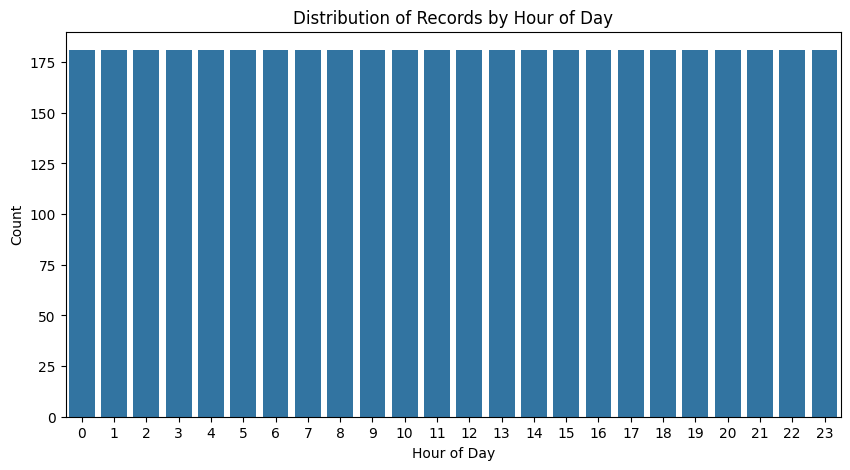

In [458]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x="hour",
    order=range(24)
)

plt.title("Distribution of Records by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Count")
plt.show()

/tmp/ipykernel_57/207837856.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(day_labels)


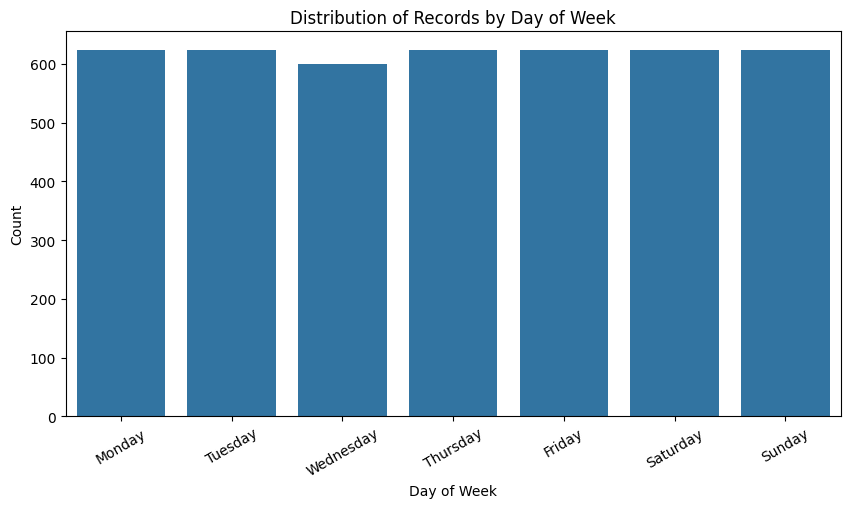

In [459]:
day_order = [0, 1, 2, 3, 4, 5, 6]
day_labels = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

plt.figure(figsize=(10, 5))

ax = sns.countplot(
    data=df,
    x="day_of_week",
    order=day_order
)

ax.set_xticklabels(day_labels)

plt.title("Distribution of Records by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.show()

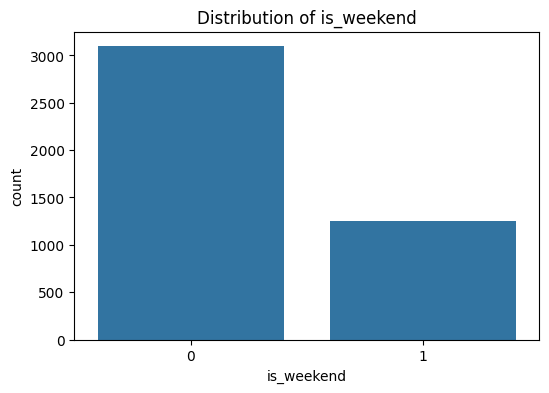

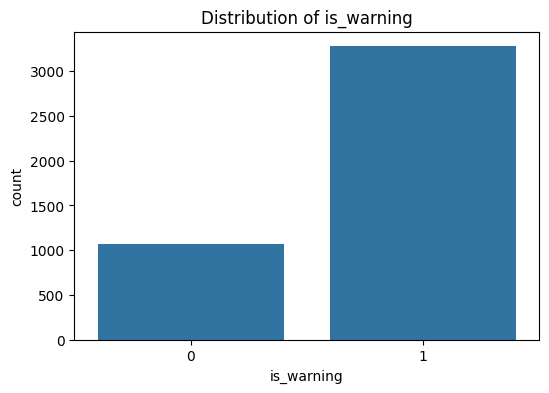

In [460]:
for col in ["is_weekend", "is_warning"]:
    plt.figure(figsize=(6, 4))
    sns.countplot(data=df, x=col)
    plt.title(f"Distribution of {col}")
    plt.show()

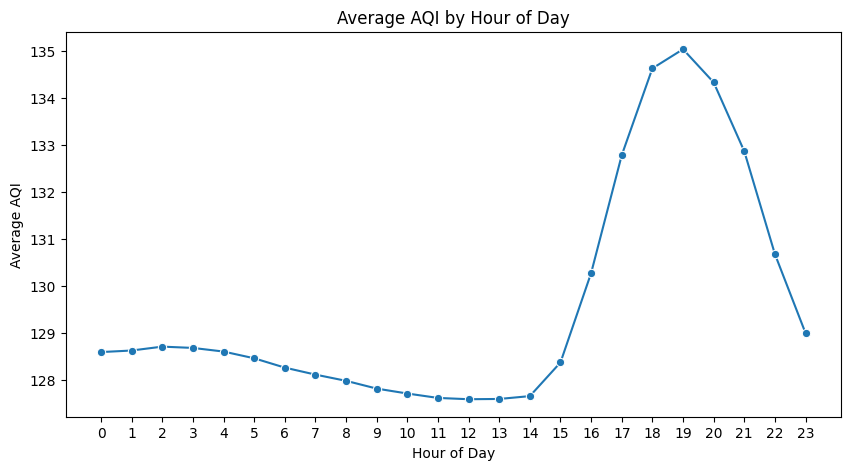

In [461]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=df,
    x="hour",
    y="aqi",
    estimator="mean",
    errorbar=None,
    marker="o"
)

plt.title("Average AQI by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Average AQI")
plt.xticks(range(24))
plt.show()

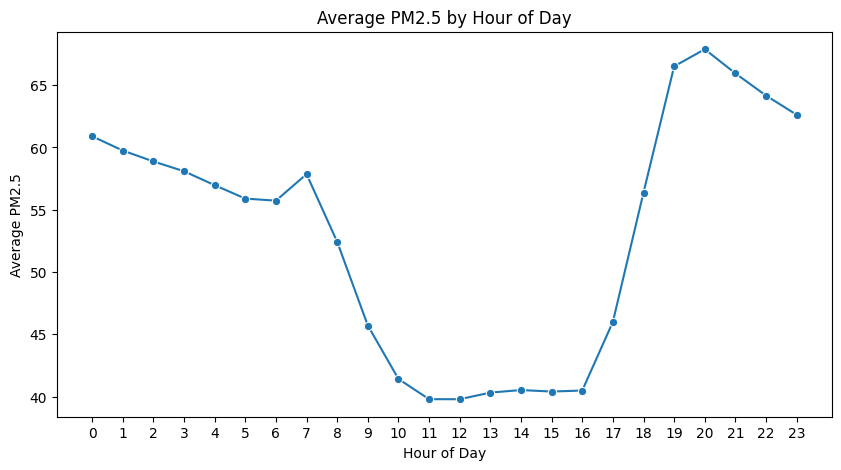

In [462]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=df,
    x="hour",
    y="pm25",
    estimator="mean",
    errorbar=None,
    marker="o"
)

plt.title("Average PM2.5 by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Average PM2.5")
plt.xticks(range(24))
plt.show()

/tmp/ipykernel_57/3004817453.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(day_labels)


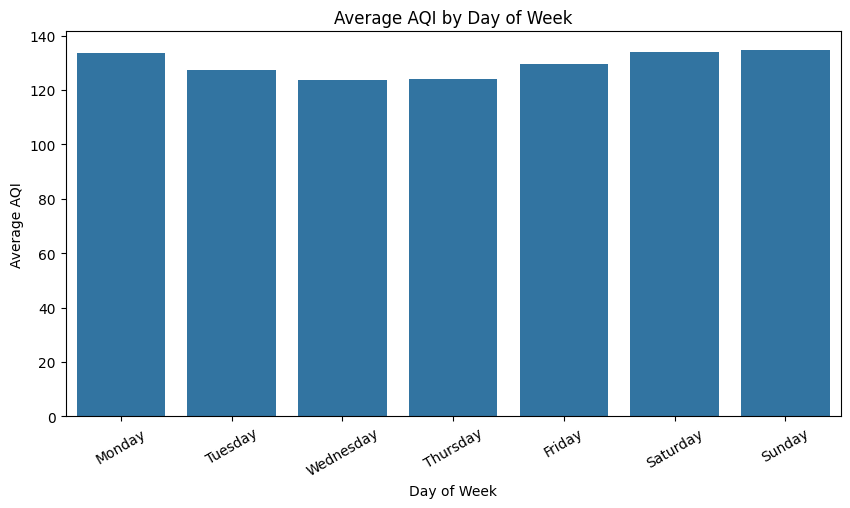

In [463]:
plt.figure(figsize=(10, 5))

ax = sns.barplot(
    data=df,
    x="day_of_week",
    y="aqi",
    order=day_order,
    estimator="mean",
    errorbar=None
)

ax.set_xticklabels(day_labels)

plt.title("Average AQI by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average AQI")
plt.xticks(rotation=30)
plt.show()

/tmp/ipykernel_57/2042345700.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(day_labels)


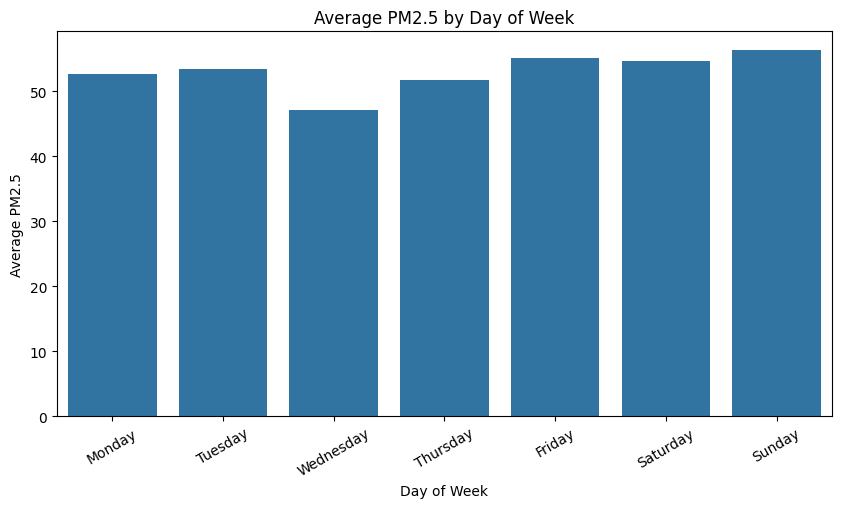

In [464]:
plt.figure(figsize=(10, 5))

ax = sns.barplot(
    data=df,
    x="day_of_week",
    y="pm25",
    order=day_order,
    estimator="mean",
    errorbar=None
)

ax.set_xticklabels(day_labels)

plt.title("Average PM2.5 by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average PM2.5")
plt.xticks(rotation=30)
plt.show()

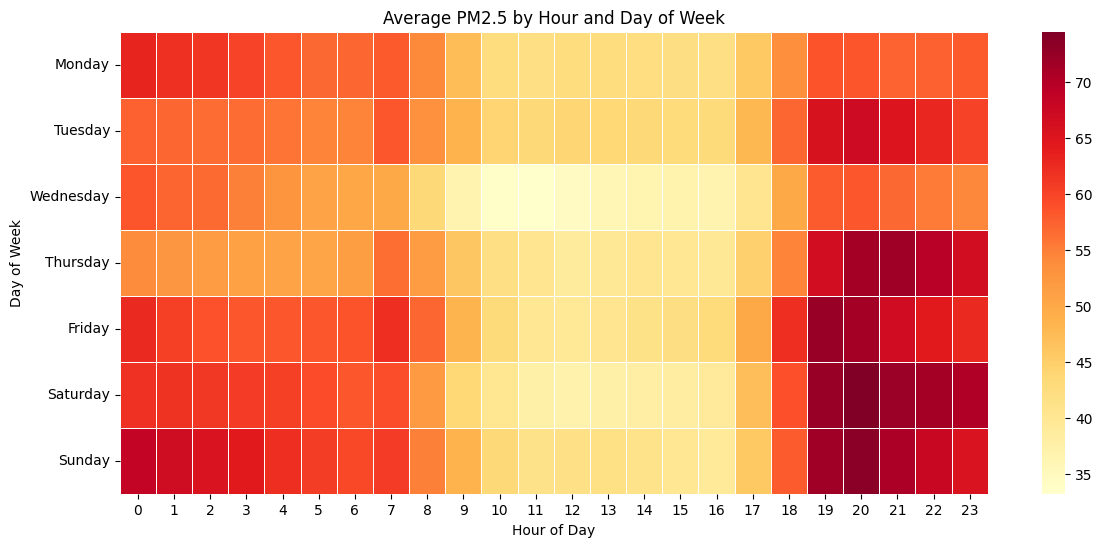

In [465]:
heatmap_data = df.pivot_table(
    values="pm25",
    index="day_of_week",
    columns="hour",
    aggfunc="mean"
)

# Make sure rows and columns appear in the correct order
heatmap_data = heatmap_data.reindex(index=day_order, columns=range(24))

plt.figure(figsize=(14, 6))

ax = sns.heatmap(
    heatmap_data,
    cmap="YlOrRd",
    linewidths=0.5,
    annot=False
)

ax.set_yticklabels(day_labels, rotation=0)

plt.title("Average PM2.5 by Hour and Day of Week")
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")
plt.show()

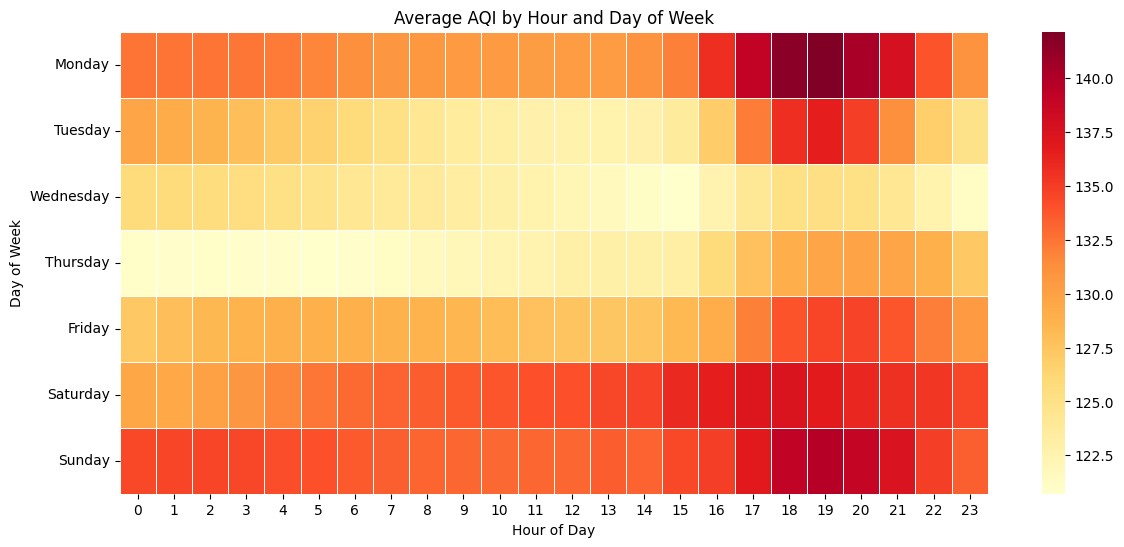

In [466]:
heatmap_data = df.pivot_table(
    values="aqi",
    index="day_of_week",
    columns="hour",
    aggfunc="mean"
)

heatmap_data = heatmap_data.reindex(index=day_order, columns=range(24))

plt.figure(figsize=(14, 6))

ax = sns.heatmap(
    heatmap_data,
    cmap="YlOrRd",
    linewidths=0.5,
    annot=False
)

ax.set_yticklabels(day_labels, rotation=0)

plt.title("Average AQI by Hour and Day of Week")
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")
plt.show()

In [467]:


df["timestamp"] = pd.to_datetime(df["timestamp"])

df["date"] = df["timestamp"].dt.normalize()

print(df[["timestamp", "date"]].head())

            timestamp       date
0 2025-11-13 00:00:00 2025-11-13
1 2025-11-13 01:00:00 2025-11-13
2 2025-11-13 02:00:00 2025-11-13
3 2025-11-13 03:00:00 2025-11-13
4 2025-11-13 04:00:00 2025-11-13


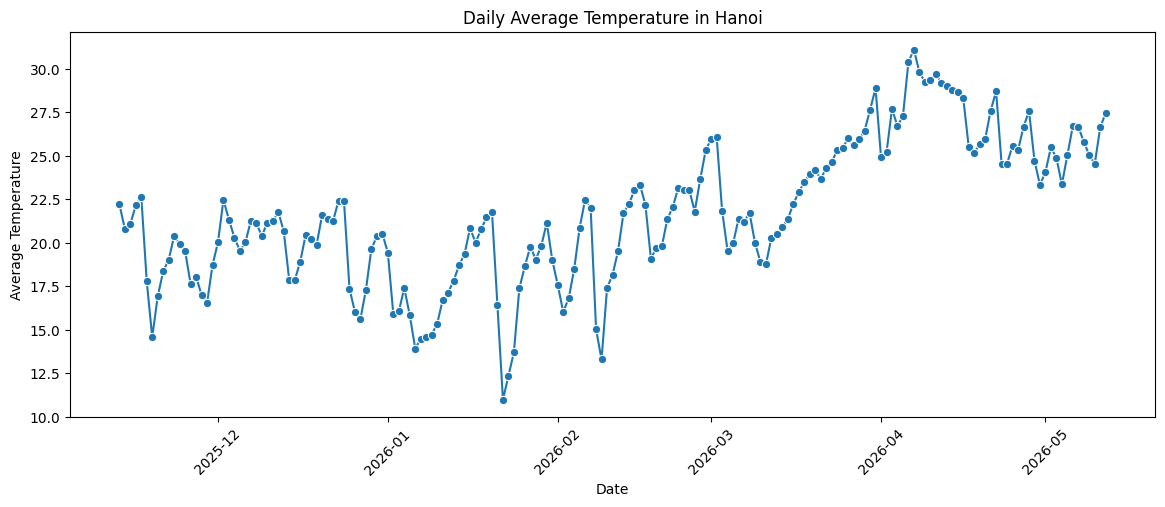

In [468]:
daily_temp = df.groupby("date")["temperature"].mean().reset_index()

plt.figure(figsize=(14, 5))

sns.lineplot(
    data=daily_temp,
    x="date",
    y="temperature",
    marker="o"
)

plt.title("Daily Average Temperature in Hanoi")
plt.xlabel("Date")
plt.ylabel("Average Temperature")
plt.xticks(rotation=45)
plt.show()

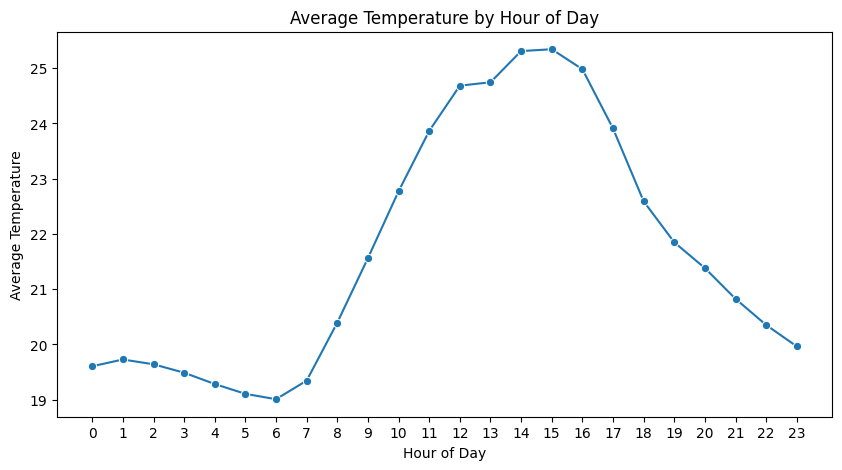

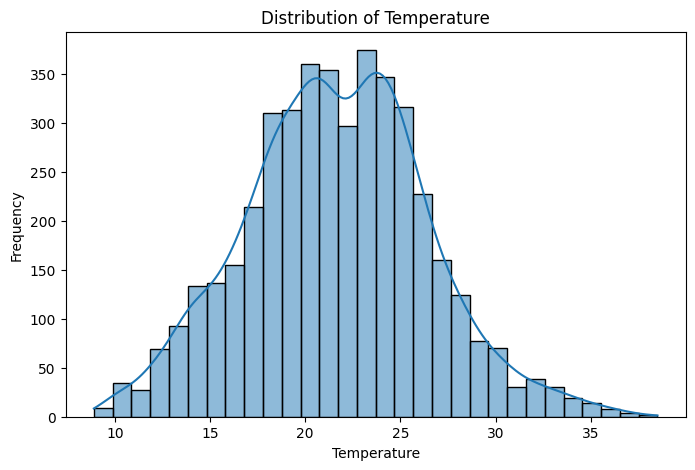

In [469]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=df,
    x="hour",
    y="temperature",
    estimator="mean",
    errorbar=None,
    marker="o"
)

plt.title("Average Temperature by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Average Temperature")
plt.xticks(range(24))
plt.show()
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="temperature",
    bins=30,
    kde=True
)

plt.title("Distribution of Temperature")
plt.xlabel("Temperature")
plt.ylabel("Frequency")
plt.show()

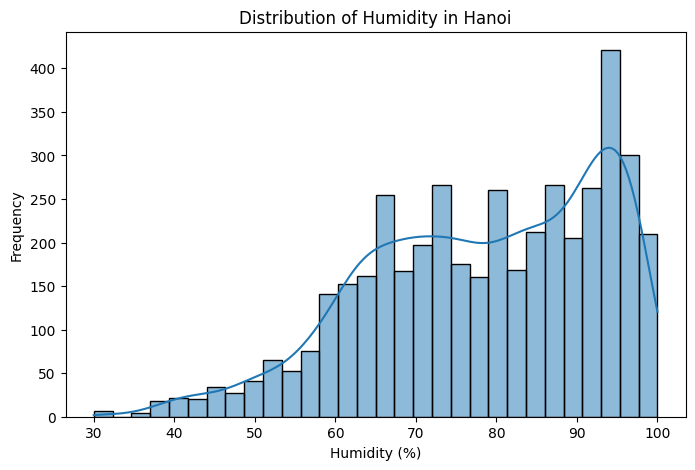

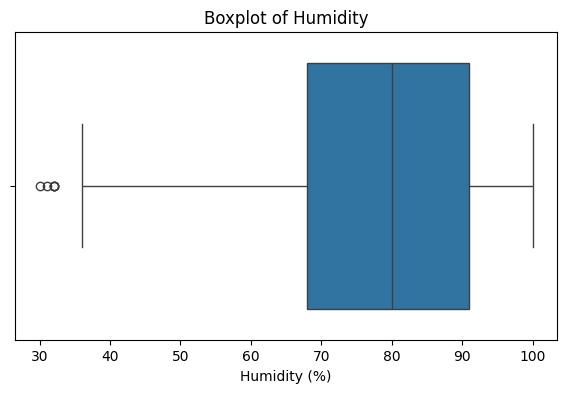

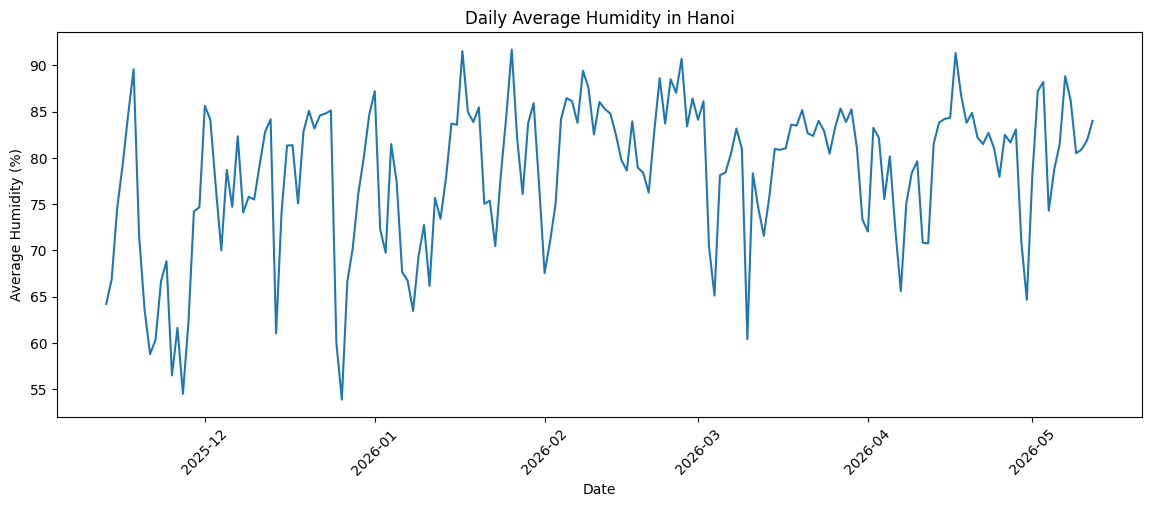

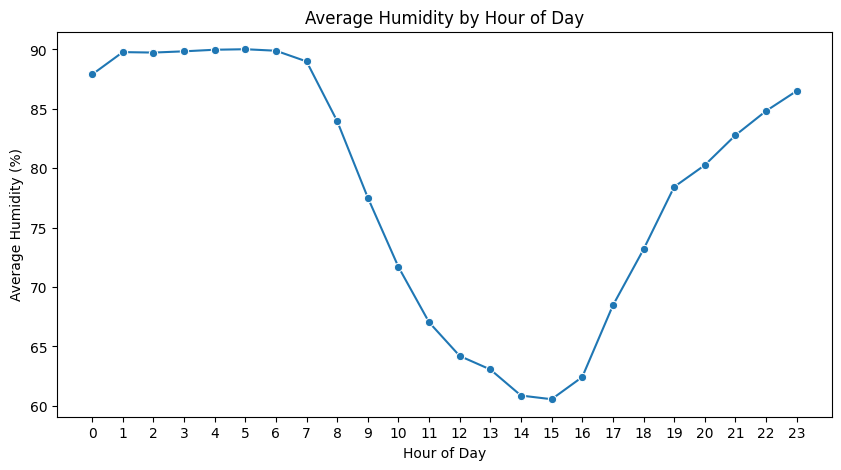

In [470]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="humidity",
    bins=30,
    kde=True
)

plt.title("Distribution of Humidity in Hanoi")
plt.xlabel("Humidity (%)")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(7, 4))

sns.boxplot(
    data=df,
    x="humidity"
)

plt.title("Boxplot of Humidity")
plt.xlabel("Humidity (%)")
plt.show()

daily_humidity = df.groupby("date")["humidity"].mean().reset_index()

plt.figure(figsize=(14, 5))

sns.lineplot(
    data=daily_humidity,
    x="date",
    y="humidity"
)

plt.title("Daily Average Humidity in Hanoi")
plt.xlabel("Date")
plt.ylabel("Average Humidity (%)")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10, 5))

sns.lineplot(
    data=df,
    x="hour",
    y="humidity",
    estimator="mean",
    errorbar=None,
    marker="o"
)

plt.title("Average Humidity by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Average Humidity (%)")
plt.xticks(range(24))
plt.show()

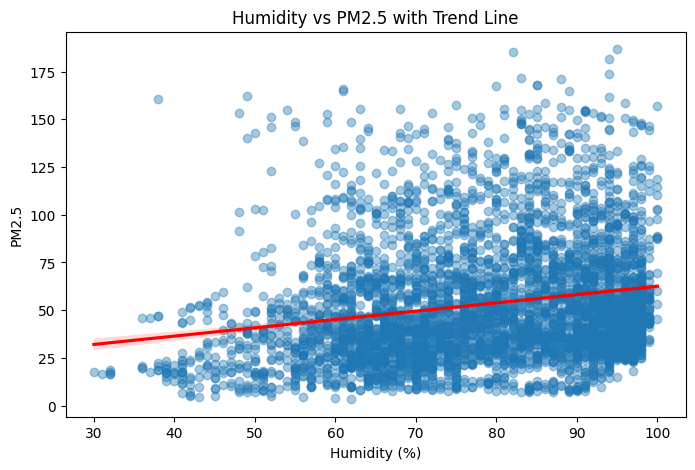

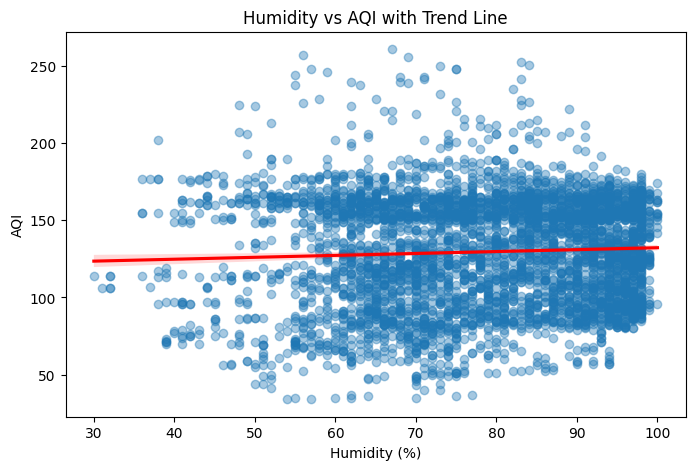

In [471]:
plt.figure(figsize=(8, 5))

sns.regplot(
    data=df,
    x="humidity",
    y="pm25",
    scatter_kws={"alpha": 0.4},
    line_kws={"color": "red"}
)

plt.title("Humidity vs PM2.5 with Trend Line")
plt.xlabel("Humidity (%)")
plt.ylabel("PM2.5")
plt.show()


plt.figure(figsize=(8, 5))

sns.regplot(
    data=df,
    x="humidity",
    y="aqi",
    scatter_kws={"alpha": 0.4},
    line_kws={"color": "red"}
)

plt.title("Humidity vs AQI with Trend Line")
plt.xlabel("Humidity (%)")
plt.ylabel("AQI")
plt.show()

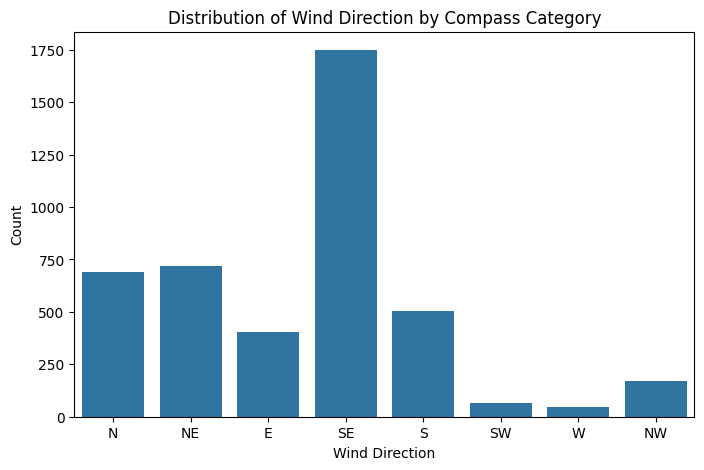

In [472]:
import numpy as np

def compass_direction(degree):
    directions = ["N", "NE", "E", "SE", "S", "SW", "W", "NW"]
    index = int((degree + 22.5) // 45) % 8
    return directions[index]

df["wind_compass"] = df["wind_direction"].apply(compass_direction)


compass_order = ["N", "NE", "E", "SE", "S", "SW", "W", "NW"]

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="wind_compass",
    order=compass_order
)

plt.title("Distribution of Wind Direction by Compass Category")
plt.xlabel("Wind Direction")
plt.ylabel("Count")
plt.show()

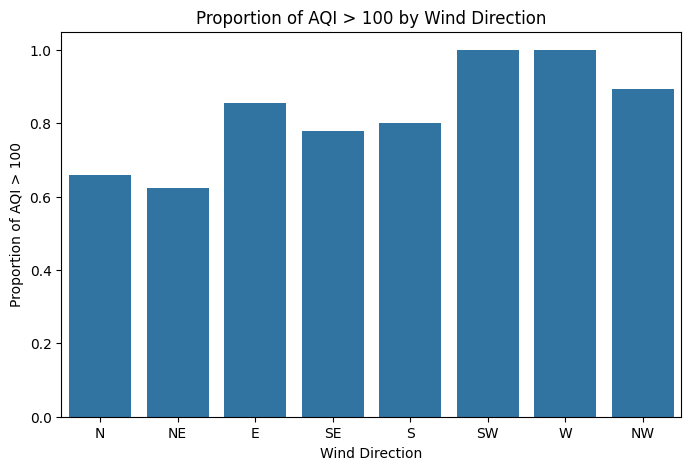

In [473]:
wind_risk = df.groupby("wind_compass")["is_warning"].mean().reset_index()

plt.figure(figsize=(8, 5))

sns.barplot(
    data=wind_risk,
    x="wind_compass",
    y="is_warning",
    order=compass_order
)

plt.title("Proportion of AQI > 100 by Wind Direction")
plt.xlabel("Wind Direction")
plt.ylabel("Proportion of AQI > 100")
plt.show()

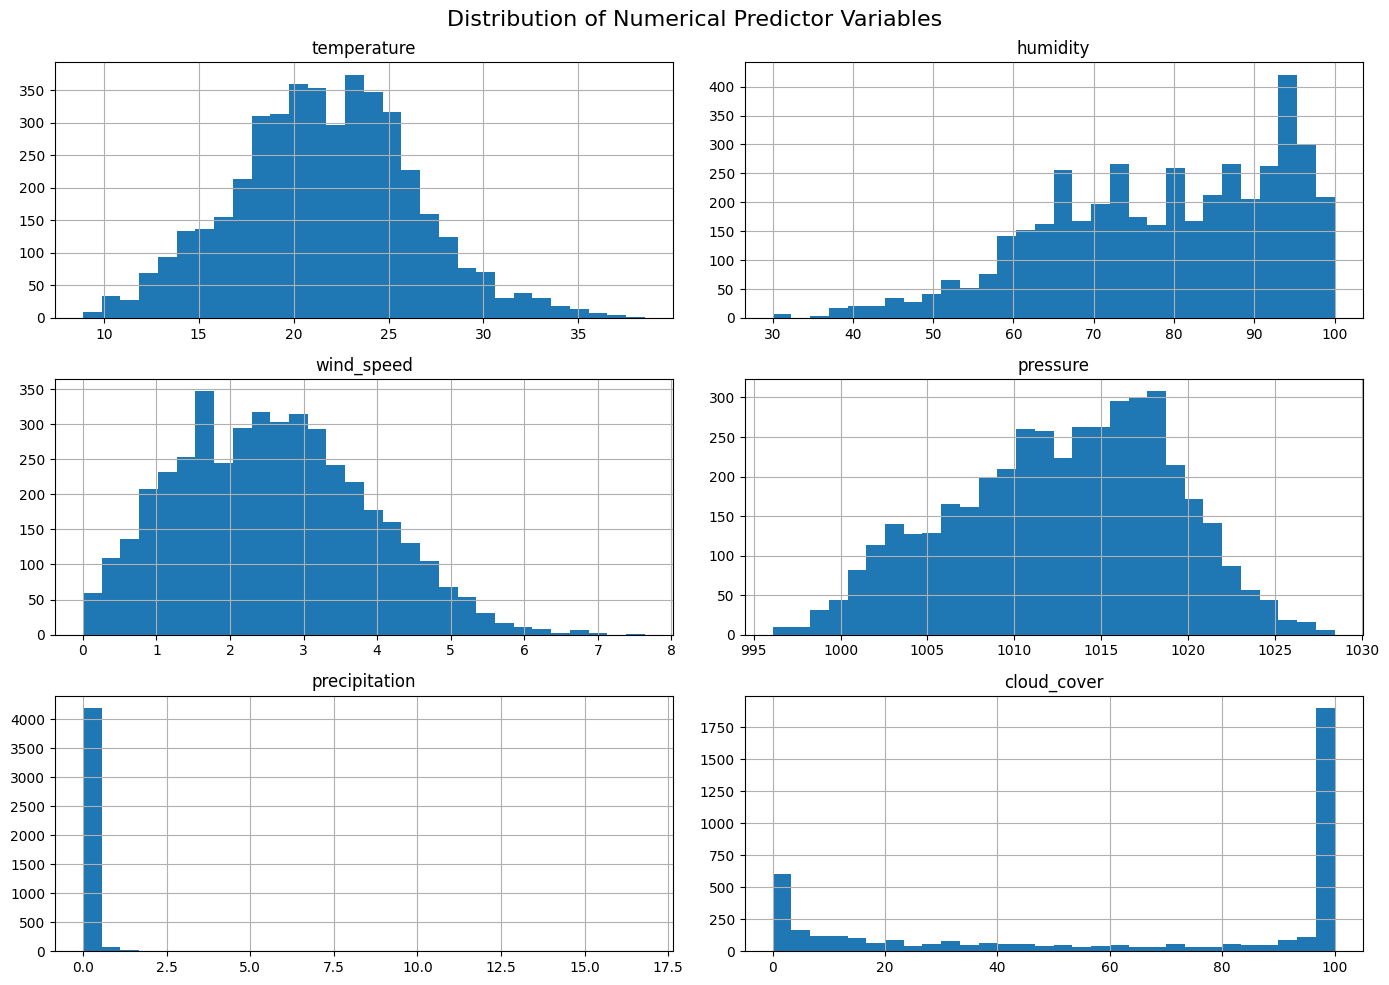

In [474]:
predictor_numeric = [
    "temperature",
    "humidity",
    "wind_speed",
    "pressure",
    "precipitation",
    "cloud_cover"
]

df[predictor_numeric].hist(
    figsize=(14, 10),
    bins=30
)

plt.suptitle("Distribution of Numerical Predictor Variables", fontsize=16)
plt.tight_layout()
plt.show()

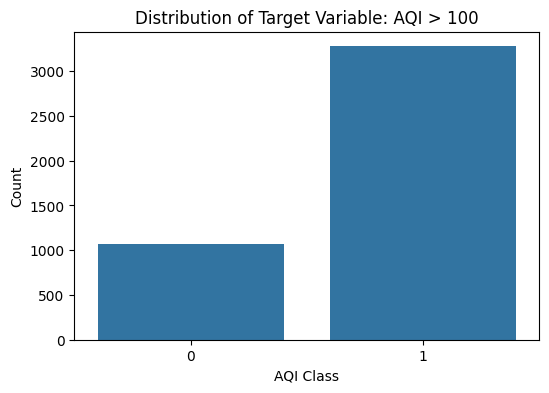

In [475]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="is_warning")
plt.title("Distribution of Target Variable: AQI > 100")
plt.xlabel("AQI Class")
plt.ylabel("Count")
plt.show()

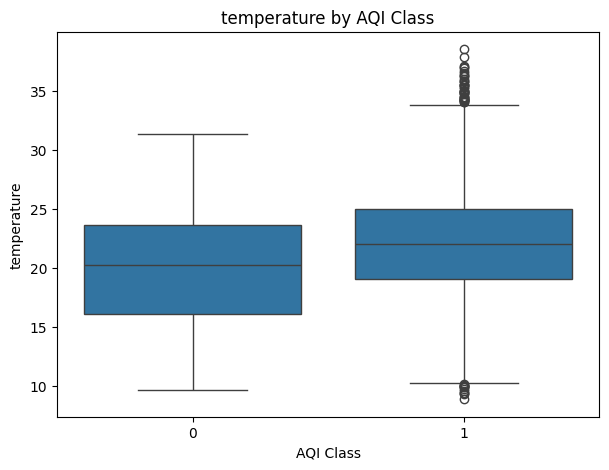

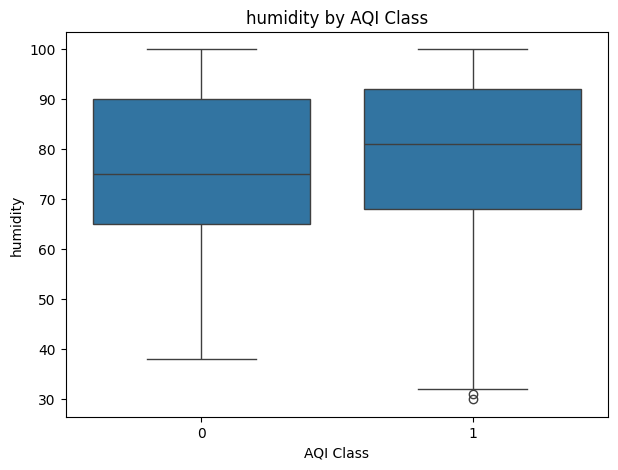

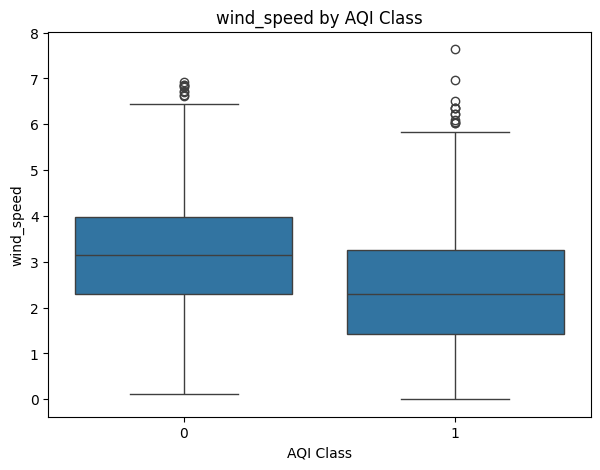

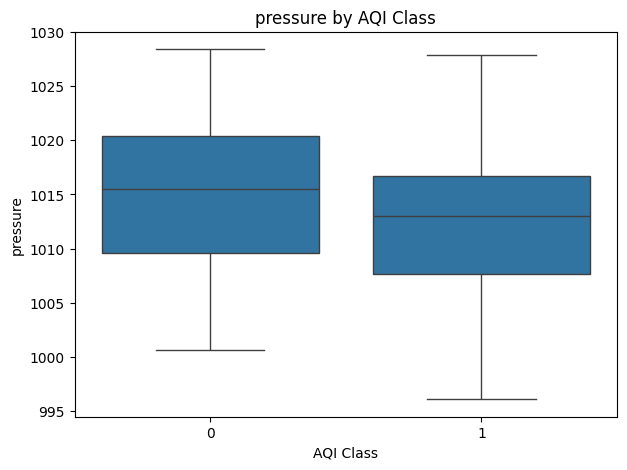

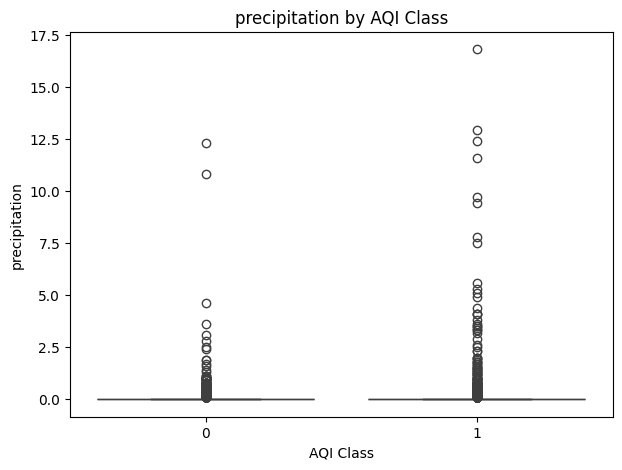

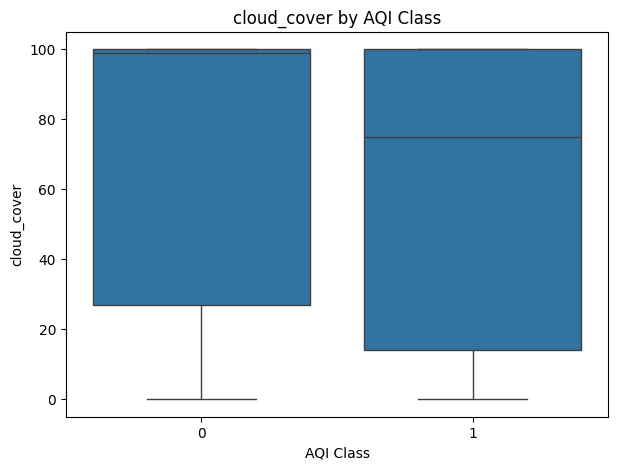

In [476]:
for col in predictor_numeric:
    plt.figure(figsize=(7, 5))
    
    sns.boxplot(
        data=df,
        x="is_warning",
        y=col
    )
    
    plt.title(f"{col} by AQI Class")
    plt.xlabel("AQI Class")
    plt.ylabel(col)
    plt.show()

/tmp/ipykernel_57/2660997419.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  risk_table = df.groupby(bin_col)["is_warning"].mean().reset_index()


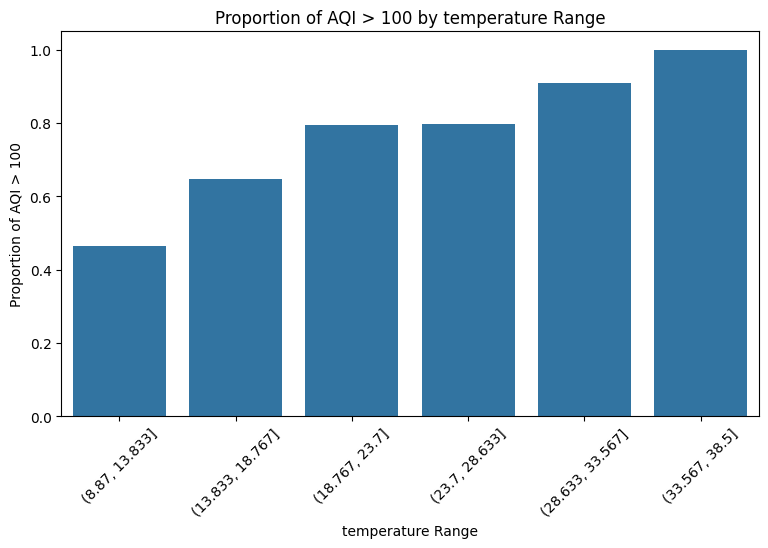

/tmp/ipykernel_57/2660997419.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  risk_table = df.groupby(bin_col)["is_warning"].mean().reset_index()


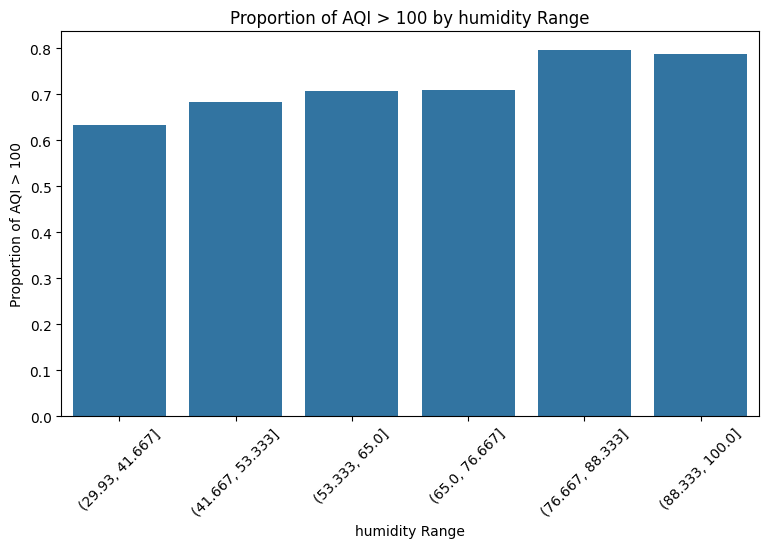

/tmp/ipykernel_57/2660997419.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  risk_table = df.groupby(bin_col)["is_warning"].mean().reset_index()


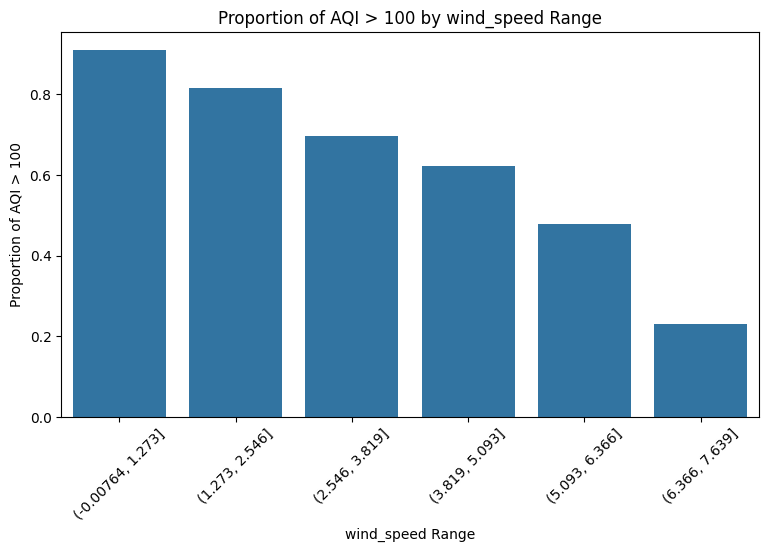

/tmp/ipykernel_57/2660997419.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  risk_table = df.groupby(bin_col)["is_warning"].mean().reset_index()


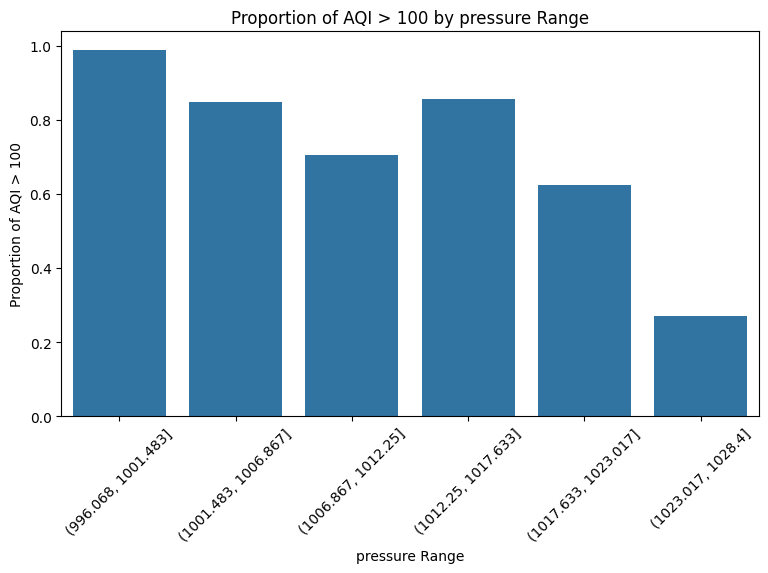

/tmp/ipykernel_57/2660997419.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  risk_table = df.groupby(bin_col)["is_warning"].mean().reset_index()


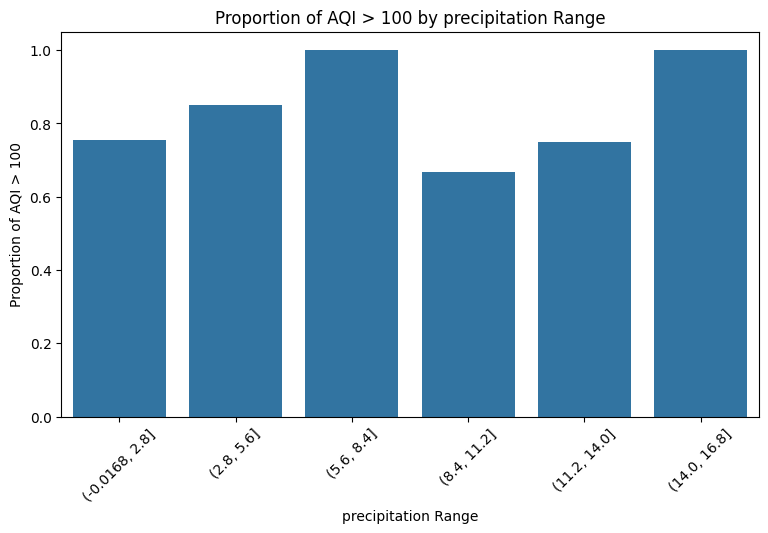

/tmp/ipykernel_57/2660997419.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  risk_table = df.groupby(bin_col)["is_warning"].mean().reset_index()


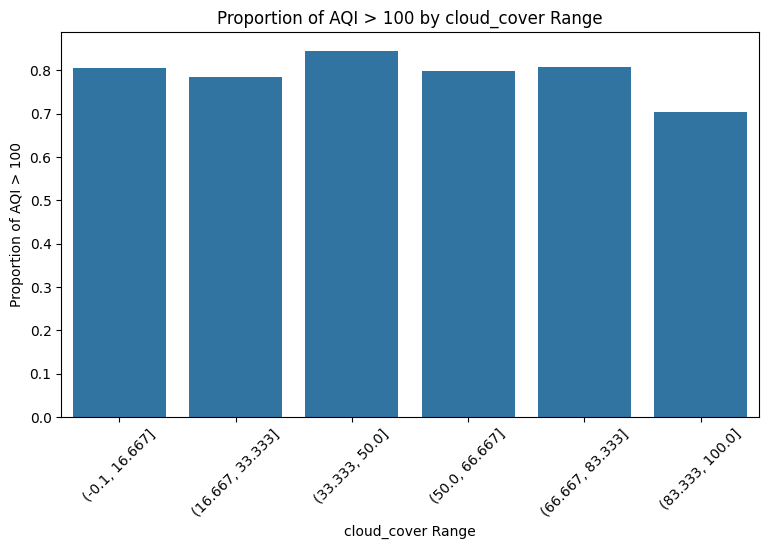

In [477]:
for col in predictor_numeric:
    bin_col = col + "_bin"
    
    df[bin_col] = pd.cut(df[col], bins=6)
    risk_table = df.groupby(bin_col)["is_warning"].mean().reset_index()
    
    plt.figure(figsize=(9, 5))
    
    sns.barplot(
        data=risk_table,
        x=bin_col,
        y="is_warning"
    )
    
    plt.title(f"Proportion of AQI > 100 by {col} Range")
    plt.xlabel(f"{col} Range")
    plt.ylabel("Proportion of AQI > 100")
    plt.xticks(rotation=45)
    plt.show()

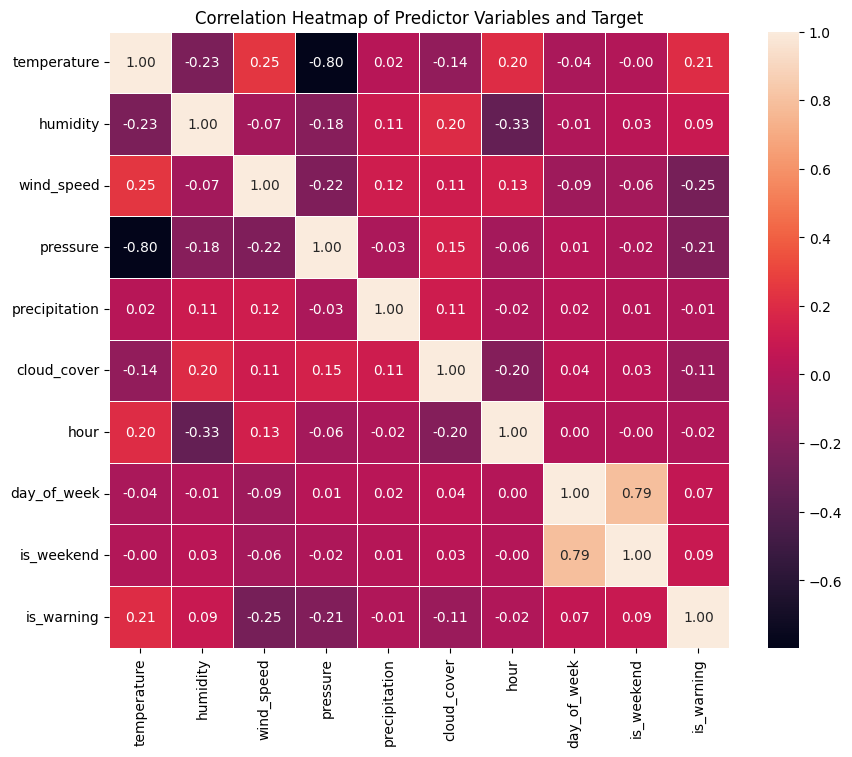

In [478]:
corr_cols = [
    "temperature",
    "humidity",
    "wind_speed",
    "pressure",
    "precipitation",
    "cloud_cover",
    "hour",
    "day_of_week",
    "is_weekend",
    "is_warning"
]

corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Predictor Variables and Target")
plt.show()

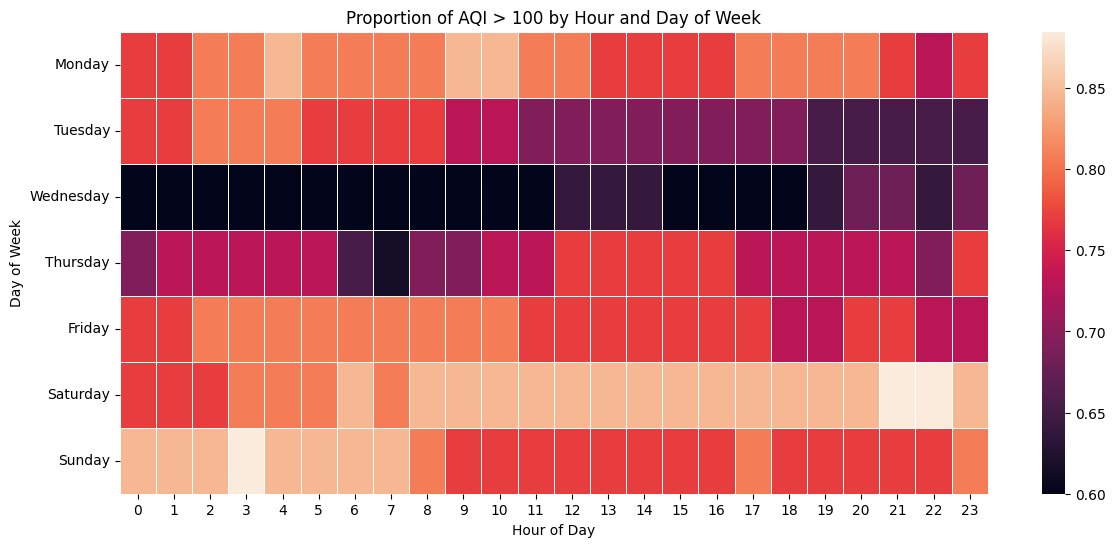

In [479]:
risk_heatmap = df.pivot_table(
    values="is_warning",
    index="day_of_week",
    columns="hour",
    aggfunc="mean"
)

risk_heatmap = risk_heatmap.reindex(index=day_order, columns=range(24))

plt.figure(figsize=(14, 6))

ax = sns.heatmap(
    risk_heatmap,
    annot=False,
    linewidths=0.5
)

ax.set_yticklabels(day_labels, rotation=0)

plt.title("Proportion of AQI > 100 by Hour and Day of Week")
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")
plt.show()